In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import warnings
import core

warnings.filterwarnings('ignore')
plt.style.use('dark_background')


# Configuration
TEST_SONG_PATH = "audio-fingerprint-identifying-python/db/Blackbird.mp3" 
db = core.Database("db/fingerprints.db")

# Loading Snippet
audio = core.load_audio(TEST_SONG_PATH, limit=10)
samples = audio['channels'][0]
Fs = audio['Fs']
print(f"Loaded {TEST_SONG_PATH} successfully. Sample Rate: {Fs}Hz")

Loaded audio-fingerprint-identifying-python/db/Blackbird.mp3 successfully. Sample Rate: 48000Hz


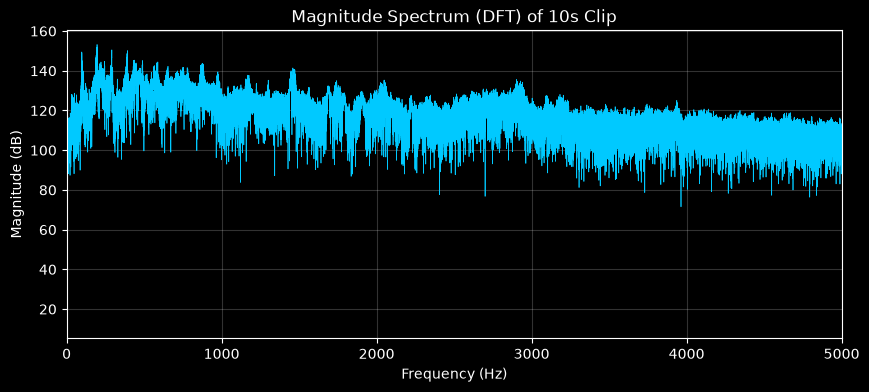

Observation: The DFT shows us exactly which frequencies exist in the clip, but the time-axis is completely destroyed. We have no idea when these frequencies occurred, making it useless for matching an audio snippet.


In [31]:
N = len(samples)
yf = fft(samples)
xf = fftfreq(N, 1/Fs)[:N//2]

plt.figure(figsize=(10, 4))
plt.plot(xf, 20 * np.log10(np.abs(yf[:N//2]) + 1e-10), color='#00C9FF', linewidth=0.5)
plt.title('Magnitude Spectrum (DFT) of 10s Clip')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.xlim(0, 5000) # Limited to 5kHz for better visibility
plt.grid(alpha=0.2)
plt.show()

print("Observation: The DFT shows us exactly which frequencies exist in the clip, but the time-axis is completely destroyed. We have no idea when these frequencies occurred, making it useless for matching an audio snippet.")

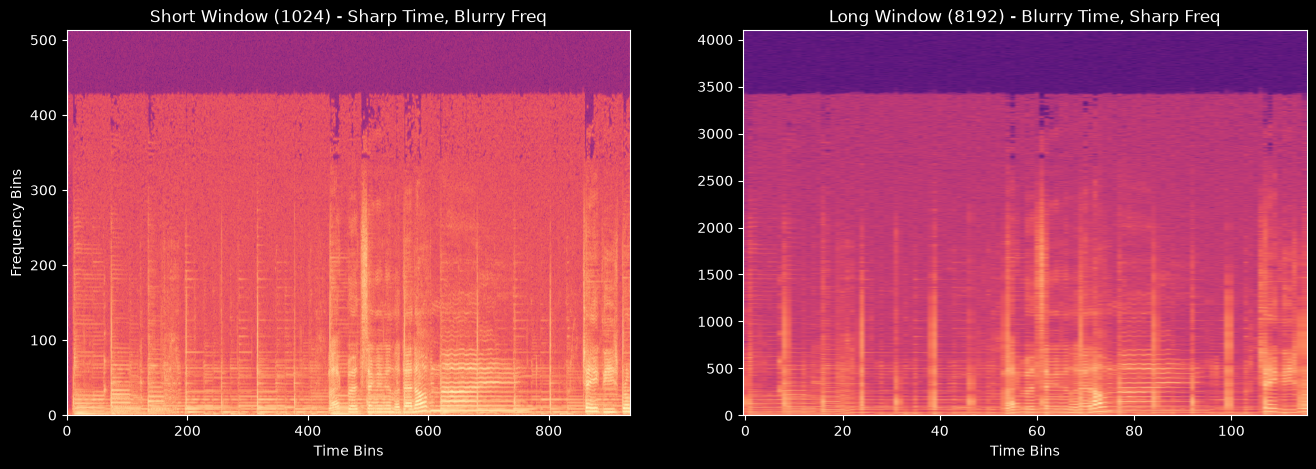

Observation: A short window gives us excellent resolution on the horizontal X-axis (timing of beats), but the vertical Y-axis (pitch) smears out. A long window gives pinpoint accuracy on pitch, but smears the timing of the beats.


In [29]:
# Short Window (wsize=1024)
spec_short = core.get_spectrogram(samples, Fs=Fs, wsize=1024)

# Long Window (wsize=8192)
spec_long = core.get_spectrogram(samples, Fs=Fs, wsize=8192)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.imshow(spec_short, aspect='auto', origin='lower', cmap='magma')
ax1.set_title('Short Window (1024) - Sharp Time, Blurry Freq')
ax1.set_ylabel('Frequency Bins')
ax1.set_xlabel('Time Bins')

ax2.imshow(spec_long, aspect='auto', origin='lower', cmap='magma')
ax2.set_title('Long Window (8192) - Blurry Time, Sharp Freq')
ax2.set_xlabel('Time Bins')

plt.show()

print("Observation: A short window gives us excellent resolution on the horizontal X-axis (timing of beats), but the vertical Y-axis (pitch) smears out. A long window gives pinpoint accuracy on pitch, but smears the timing of the beats.")

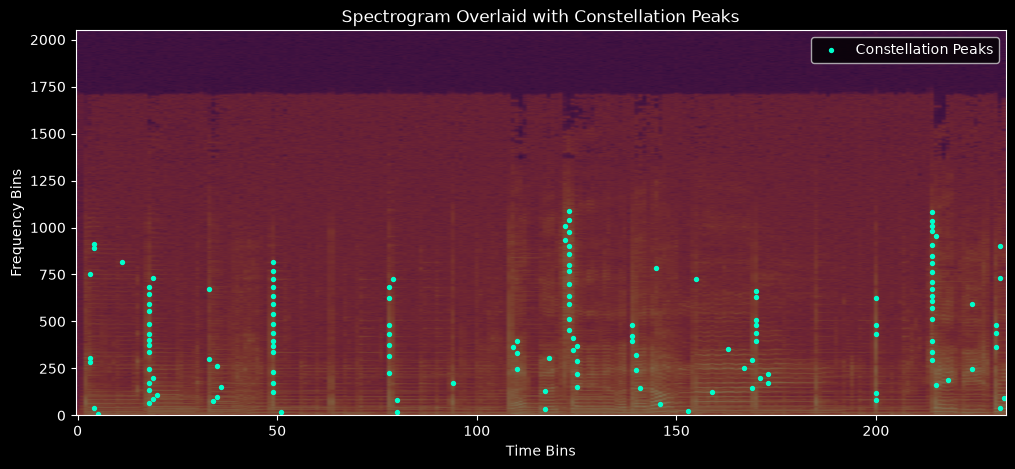

In [ ]:
# Generating standard spectrogram and extracting peaks
spec_default = core.get_spectrogram(samples, Fs=Fs)
peaks = core.get_2D_peaks(spec_default) # Peaks return as (freq_idx, time_idx)

time_idx = [p[1] for p in peaks]
freq_idx = [p[0] for p in peaks]

plt.figure(figsize=(12, 5))
plt.imshow(spec_default, aspect='auto', origin='lower', cmap='magma', alpha=0.5)
plt.scatter(time_idx, freq_idx, color='#00FFCC', s=8, label='Constellation Peaks')
plt.title('Spectrogram Overlaid with Constellation Peaks')
plt.xlabel('Time Bins')
plt.ylabel('Frequency Bins')
plt.legend()
plt.show()

In [28]:
hashes = list(core.generate_hashes(peaks))

unique_freq_bins = len(set(freq_idx))
unique_hash_strings = len(set([h[0] for h in hashes]))

print(f"Total Peaks Extracted: {len(peaks)}")
print(f"Total Hashes Generated: {len(hashes)}\n")

print(f"Unique 'Single Peak' Identifiers available: {unique_freq_bins}")
print(f"Unique 'Paired Hash' Identifiers available: {unique_hash_strings}")

print("\nObservation: If we only matched single peaks, we only have a few hundred possible frequency bins to choose from. This leads to massive 'hash collisions' (false positives) where every song shares the same frequencies. By pairing two frequencies and their time gap (f1|f2|dt), we exponentially expand the combinations into millions of unique identifiers, making a match mathematically decisive.")

Total Peaks Extracted: 143
Total Hashes Generated: 1897

Unique 'Single Peak' Identifiers available: 125
Unique 'Paired Hash' Identifiers available: 1889

Observation: If we only matched single peaks, we only have a few hundred possible frequency bins to choose from. This leads to massive 'hash collisions' (false positives) where every song shares the same frequencies. By pairing two frequencies and their time gap (f1|f2|dt), we exponentially expand the combinations into millions of unique identifiers, making a match mathematically decisive.


In [ ]:
# Noise Experiment
import numpy as np

noise_levels = [0.01, 0.05, 0.1, 0.2, 0.5]
rms_amplitude = np.sqrt(np.mean(samples.astype(float)**2))

for noise_amt in noise_levels:
    noise = np.random.normal(0, rms_amplitude * noise_amt, len(samples))
    noisy_samples = np.int16(np.clip(samples + noise, -32768, 32767))
    
    spec_noise = core.get_spectrogram(noisy_samples, Fs=Fs)
    peaks_noise = core.get_2D_peaks(spec_noise)
    hashes_noise = list(core.generate_hashes(peaks_noise))
    
    matches = db.find_matches(hashes_noise)
    alignment = core.align_matches(matches, db)
    
    if alignment:
         print(f"Noise {noise_amt*100:2.0f}%  Match: '{alignment['song_name']}'  Confidence: {alignment['confidence']} spikes")
    else:
         print(f"Noise {noise_amt*100:2.0f}%  Match: FAILED")

print("\nObservation: We observed that the baseline matching algorithm fails completely even at low levels of added white noise (1%).")

Noise  1%  Match: FAILED
Noise  5%  Match: FAILED
Noise 10%  Match: FAILED
Noise 20%  Match: FAILED
Noise 50%  Match: FAILED

Observation: We observed that the baseline matching algorithm fails completely even at low levels of added white noise (1%).


In [ ]:
# Pitch-Shifting Experiment
# To simulate a pitch shift, 
# we use pydub to play the audio 5% faster (changing pitch and speed simultaneously)
audio_segment = core.AudioSegment.from_file(TEST_SONG_PATH)[:10000]

# Shift pitch/speed up by 5%
new_sample_rate = int(audio_segment.frame_rate * 1.05)
shifted_audio = audio_segment._spawn(audio_segment.raw_data, overrides={'frame_rate': new_sample_rate})
shifted_audio = shifted_audio.set_frame_rate(audio_segment.frame_rate)

data = np.frombuffer(shifted_audio._data, dtype=np.int16)
shifted_samples = data[0::shifted_audio.channels]

spec_shift = core.get_spectrogram(shifted_samples, Fs=Fs)
peaks_shift = core.get_2D_peaks(spec_shift)
hashes_shift = list(core.generate_hashes(peaks_shift))

matches_shift = db.find_matches(hashes_shift)
alignment_shift = core.align_matches(matches_shift, db)

if alignment_shift:
    print(f"Pitch Shift 5%  Match: '{alignment_shift['song_name']}'")
else:
    print(f"Pitch Shift 5%  Match: FAILED")

print("\nObservation: Pitch shifting moves the constellation peaks up or down the vertical frequency axis. Because our hash formula (f1|f2|dt) strictly relies on exact frequency bins, a shift changes the textual output of the SHA-1 hash completely. To make the system robust to pitch shifting, we could hash the *ratio* of the frequencies (f1/f2) instead of the absolute frequencies.")

Pitch Shift 5%  Match: FAILED

Observation: Pitch shifting moves the constellation peaks up or down the vertical frequency axis. Because our hash formula (f1|f2|dt) strictly relies on exact frequency bins, a shift changes the textual output of the SHA-1 hash completely. To make the system robust to pitch shifting, we could hash the *ratio* of the frequencies (f1/f2) instead of the absolute frequencies.
